<a href="https://colab.research.google.com/github/wagborba/calculadora-dfc/blob/main/04_previsao_tempo_entrega_QNN_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsão de Tempo de Entrega — Regressão com QNN

Este notebook foi feito para a atividade prática de QNN.

O aluno deve mudar apenas as listas de parâmetros, rodar os testes, escolher uma configuração final e copiar os gráficos para o relatório.

**O código gera:**

1. gráfico da loss ao final de cada configuração;
2. tabela simples com os resultados;
3. gráfico final de loss;
4. gráfico final de treino vs teste;
5. gráfico final variando camadas e qubits, com nome, CPF, data e horário fora da área principal do gráfico.


In [ ]:
# PREENCHA ANTES DE RODAR O NOTEBOOK
NOME = "Aluno"
CPF = "12921210"

if NOME.strip() == "" or CPF.strip() == "":
    print("ATENÇÃO: preencha NOME e CPF antes de continuar.")
else:
    print(f"Aluno(a): {NOME} | CPF: {CPF}")


Aluno(a): Aluno | CPF: 12921210


In [ ]:
# Imports básicos
# Se estiver no Google Colab e não tiver PennyLane instalado, descomente a linha abaixo.
!pip install -q pennylane

import time
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import pennylane as qml

# IMPORTANTE:
# Usamos float64 em tudo para evitar erro do tipo:
# RuntimeError: Found dtype Float but expected Double
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

np.random.seed(42)
torch.manual_seed(42)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 44.4 MB/s eta 0:00:00


In [ ]:
# ======================================================
# PARÂMETROS QUE OS ALUNOS PODEM MUDAR
# ======================================================

# Comece com listas pequenas para rodar rápido.
# Depois, teste mais valores se quiser.
LEARNING_RATES = [0.1]
EPOCHS_LIST = [100]
LAYERS_LIST = [2]
QUBITS_LIST = [3]

# Dados simulados da atividade
N_AMOSTRAS = 80
TEST_RATIO = 0.25
SEED_DADOS = 42

# Para o gráfico 3 final, o código compara camadas e qubits
# mantendo o learning rate e o número de épocas escolhidos no final.


In [ ]:
# ======================================================
# FUNÇÕES DE NORMALIZAÇÃO
# ======================================================
# Aqui o min-max fica definido corretamente.
# Não existe chamada para uma função "minmax" solta/indefinida.

def minmax_fit(X):
    minimo = X.min(axis=0, keepdims=True)
    maximo = X.max(axis=0, keepdims=True)
    return minimo, maximo


def minmax_transform(X, minimo, maximo):
    return (X - minimo) / (maximo - minimo + 1e-8)


def minmax_fit_transform(X):
    minimo, maximo = minmax_fit(X)
    return minmax_transform(X, minimo, maximo), minimo, maximo


def separar_treino_teste(X, y, test_ratio=0.25, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)

    corte = int(len(X) * (1 - test_ratio))
    idx_treino = idx[:corte]
    idx_teste = idx[corte:]

    return X[idx_treino], y[idx_treino], X[idx_teste], y[idx_teste]


## 1. Preparação dos dados

In [ ]:
# ======================================================
# DADOS SIMULADOS — PREVISÃO DE TEMPO DE ENTREGA
# ======================================================
PROBLEMA = "Previsão de tempo de entrega"
FEATURES = [
    "distancia_km",
    "numero_paradas",
    "transito",
    "prioridade",
]


def preparar_dados(n=N_AMOSTRAS, test_ratio=TEST_RATIO, seed=SEED_DADOS):
    global Y_MIN, Y_MAX

    rng = np.random.default_rng(seed)

    distancia_km = rng.uniform(2, 80, n)
    numero_paradas = rng.integers(0, 8, n).astype(np.float64)
    transito = rng.uniform(0, 1, n)
    prioridade = rng.uniform(0, 1, n)

    X = np.stack([
        distancia_km,
        numero_paradas,
        transito,
        prioridade,
    ], axis=1)

    y = (
        0.35 * distancia_km
        + 7.0 * numero_paradas
        + 35.0 * transito
        - 10.0 * prioridade
        + rng.normal(0, 6, n)
    )
    y = np.maximum(y, 5).astype(np.float64)

    Xtr_np, ytr_np, Xte_np, yte_np = separar_treino_teste(X, y, test_ratio, seed)

    Xtr_np, X_min, X_max = minmax_fit_transform(Xtr_np)
    Xte_np = minmax_transform(Xte_np, X_min, X_max)

    Y_MIN = float(ytr_np.min())
    Y_MAX = float(ytr_np.max())
    ytr_np = (ytr_np - Y_MIN) / (Y_MAX - Y_MIN + 1e-8)
    yte_np = (yte_np - Y_MIN) / (Y_MAX - Y_MIN + 1e-8)

    return (
        torch.tensor(Xtr_np, dtype=DTYPE),
        torch.tensor(ytr_np, dtype=DTYPE),
        torch.tensor(Xte_np, dtype=DTYPE),
        torch.tensor(yte_np, dtype=DTYPE),
    )


Xtr, ytr, Xte, yte = preparar_dados()

print("Problema:", PROBLEMA)
print("Features:", FEATURES)
print("Formato treino:", Xtr.shape, ytr.shape)
print("Formato teste:", Xte.shape, yte.shape)
print("Escala original do alvo: min =", Y_MIN, "| max =", Y_MAX)


Problema: Previsão de tempo de entrega
Features: ['distancia_km', 'numero_paradas', 'transito', 'prioridade']
Formato treino: torch.Size([60, 4]) torch.Size([60])
Formato teste: torch.Size([20, 4]) torch.Size([20])
Escala original do alvo: min = 5.0 | max = 100.86161563815934


## 2. Modelo QNN

In [ ]:
# ======================================================
# MODELO QNN SIMPLES
# ======================================================

def ajustar_features_para_qubits(X, n_qubits):
    """Seleciona as primeiras features ou completa com zeros para bater com n_qubits."""
    X = X.to(dtype=DTYPE)

    if X.shape[1] >= n_qubits:
        return X[:, :n_qubits]

    faltam = n_qubits - X.shape[1]
    zeros = torch.zeros((X.shape[0], faltam), dtype=DTYPE)
    return torch.cat([X, zeros], dim=1)


class QNN(torch.nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.dev = qml.device("default.qubit", wires=n_qubits)

        # Parâmetros treináveis do circuito.
        # torch.nn.Parameter garante que o tensor é leaf e treinável pelo otimizador.
        self.weights = torch.nn.Parameter(
            0.1 * torch.randn(n_layers, n_qubits, 3, dtype=DTYPE)
        )
        self.bias = torch.nn.Parameter(torch.zeros(1, dtype=DTYPE))

        @qml.qnode(self.dev, interface="torch", diff_method="backprop")
        def circuito(x, weights):
            # Feature map: dados clássicos -> rotações quânticas
            qml.AngleEmbedding(np.pi * x, wires=range(n_qubits), rotation="Y")

            # Ansatz variacional
            qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

            # Readout: valor esperado de Z no primeiro qubit
            return qml.expval(qml.PauliZ(0))

        self.circuito = circuito

    def forward(self, X):
        saidas = []
        for x in X:
            saidas.append(self.circuito(x, self.weights))
        saidas = torch.stack(saidas).reshape(-1)
        return saidas + self.bias[0]


## 3. Funções de treino

In [ ]:
# ======================================================
# TREINAMENTO E MÉTRICAS — REGRESSÃO
# ======================================================

def desfazer_minmax_y(y_norm):
    return y_norm * (Y_MAX - Y_MIN) + Y_MIN


def metricas_regressao(pred_norm, y_norm):
    pred = desfazer_minmax_y(pred_norm)
    y_real = desfazer_minmax_y(y_norm)

    mse = torch.mean((pred - y_real) ** 2).item()
    mae = torch.mean(torch.abs(pred - y_real)).item()
    return mse, mae


def treinar_qnn(lr, epochs, n_layers, n_qubits):
    Xtr_q = ajustar_features_para_qubits(Xtr, n_qubits)
    Xte_q = ajustar_features_para_qubits(Xte, n_qubits)

    model = QNN(n_qubits=n_qubits, n_layers=n_layers)
    loss_fn = torch.nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    inicio = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        pred = model(Xtr_q)
        loss = loss_fn(pred, ytr)

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_history.append(float(loss.item()))

    model.eval()
    with torch.no_grad():
        pred_tr = model(Xtr_q)
        pred_te = model(Xte_q)

        mse_tr, mae_tr = metricas_regressao(pred_tr, ytr)
        mse_te, mae_te = metricas_regressao(pred_te, yte)

    return {
        "lr": lr,
        "epochs": epochs,
        "layers": n_layers,
        "qubits": n_qubits,
        "loss_history": loss_history,
        "train_metric": mae_tr,
        "test_metric": mae_te,
        "train_mse": mse_tr,
        "test_mse": mse_te,
        "metric_name": "MAE",
        "tempo_seg": time.perf_counter() - inicio,
        "model": model,
    }


def plotar_loss_configuracao(r):
    plt.figure(figsize=(6, 3.5))
    plt.plot(r["loss_history"])
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(
        f"Loss finalizada | lr={r['lr']} | épocas={r['epochs']} | "
        f"camadas={r['layers']} | qubits={r['qubits']}"
    )
    plt.grid(True, alpha=0.3)
    plt.show()


## 4. Rodar várias configurações

Rodando: lr=0.1, epochs=100, camadas=2, qubits=3


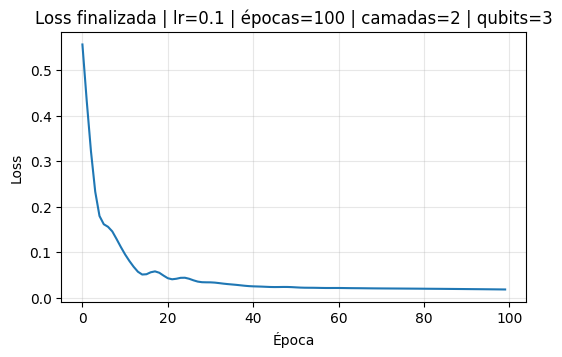


Tabela de resultados:
 id  lr  epochs  camadas  qubits  MAE treino  MAE teste  MSE treino  MSE teste  loss final  tempo (s)
  0 0.1     100        2       3   10.064465  11.029938  165.360258 251.315109    0.018106  81.888854


In [ ]:
# ======================================================
# RODAR AS CONFIGURAÇÕES
# ======================================================
# Quando cada configuração termina, o código plota a loss daquela configuração.

resultados = []

for lr in LEARNING_RATES:
    for epochs in EPOCHS_LIST:
        for layers in LAYERS_LIST:
            for qubits in QUBITS_LIST:
                print(f"Rodando: lr={lr}, epochs={epochs}, camadas={layers}, qubits={qubits}")
                r = treinar_qnn(lr=lr, epochs=epochs, n_layers=layers, n_qubits=qubits)
                resultados.append(r)
                plotar_loss_configuracao(r)


def montar_tabela_resultados(resultados):
    linhas = []
    for i, r in enumerate(resultados):
        linhas.append({
            "id": i,
            "lr": r["lr"],
            "epochs": r["epochs"],
            "camadas": r["layers"],
            "qubits": r["qubits"],
            "MAE treino": r["train_metric"],
            "MAE teste": r["test_metric"],
            "MSE treino": r["train_mse"],
            "MSE teste": r["test_mse"],
            "loss final": r["loss_history"][-1],
            "tempo (s)": r["tempo_seg"],
        })
    return pd.DataFrame(linhas).sort_values("MAE teste", ascending=True)

resultados_df = montar_tabela_resultados(resultados)
print("\nTabela de resultados:")
print(resultados_df.to_string(index=False))


## 5. Escolher uma configuração final

In [ ]:
# ======================================================
# ESCOLHA FINAL DO ALUNO
# ======================================================
# Escolha uma configuração para usar nos gráficos finais.
# Ela pode ser uma configuração já rodada acima.
# Se não tiver sido rodada, o código treina essa configuração agora.

SELECTED_LR = 0.08
SELECTED_EPOCHS = 1000
SELECTED_LAYERS = 2
SELECTED_QUBITS = 3


def obter_resultado_escolhido():
    global resultados, resultados_df

    for r in resultados:
        if (
            r["lr"] == SELECTED_LR
            and r["epochs"] == SELECTED_EPOCHS
            and r["layers"] == SELECTED_LAYERS
            and r["qubits"] == SELECTED_QUBITS
        ):
            return r

    print("Configuração escolhida não estava na lista rodada. Treinando agora...")
    r = treinar_qnn(
        lr=SELECTED_LR,
        epochs=SELECTED_EPOCHS,
        n_layers=SELECTED_LAYERS,
        n_qubits=SELECTED_QUBITS,
    )
    resultados.append(r)
    plotar_loss_configuracao(r)
    resultados_df = montar_tabela_resultados(resultados)
    return r


escolhido = obter_resultado_escolhido()

print("Configuração escolhida:")
print(f"lr = {escolhido['lr']}")
print(f"épocas = {escolhido['epochs']}")
print(f"camadas = {escolhido['layers']}")
print(f"qubits = {escolhido['qubits']}")
print(f"MAE treino = {escolhido['train_metric']:.4f}")
print(f"MAE teste = {escolhido['test_metric']:.4f}")
print(f"MSE treino = {escolhido['train_mse']:.4f}")
print(f"MSE teste = {escolhido['test_mse']:.4f}")
print(f"Tempo = {escolhido['tempo_seg']:.2f} s")


Configuração escolhida não estava na lista rodada. Treinando agora...


## 6. Gráficos finais e tabela-resumo

In [ ]:
# ======================================================
# GRÁFICOS FINAIS PARA O RELATÓRIO
# ======================================================

# Gráfico 1 — Loss por época
plt.figure(figsize=(7, 4))
plt.plot(escolhido["loss_history"])
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Gráfico 1 — Loss por época")
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico 2 — Métrica de treino e teste
plt.figure(figsize=(5, 4))
plt.bar(["Treino", "Teste"], [escolhido["train_metric"], escolhido["test_metric"]])
plt.ylabel("MAE")
plt.title("Gráfico 2 — Métrica de treino e teste")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# Gráfico 3 — Resultado variando camadas e qubits
# Mantém o learning rate e o número de épocas escolhidos.
df_plot = resultados_df[
    (resultados_df["lr"] == SELECTED_LR) &
    (resultados_df["epochs"] == SELECTED_EPOCHS)
]

if len(df_plot) == 0:
    df_plot = resultados_df.copy()

fig, ax = plt.subplots(figsize=(7, 4.5))
for q in sorted(df_plot["qubits"].unique()):
    dfq = df_plot[df_plot["qubits"] == q].sort_values("camadas")
    ax.plot(dfq["camadas"], dfq["MAE teste"], marker="o", label=f"{q} qubits")

ax.set_xlabel("Número de camadas")
ax.set_ylabel("MAE no teste")
ax.set_title("Gráfico 3 — Desempenho variando camadas e qubits")
ax.grid(True, alpha=0.3)
ax.legend()

agora = datetime.now().strftime("%d/%m/%Y %H:%M:%S")
fig.subplots_adjust(bottom=0.25)
fig.text(0.01, 0.04, f"Nome: {NOME} | CPF: {CPF} | Rodado em: {agora}", fontsize=9)
plt.show()

# Tabela-resumo para ajudar a preencher o relatório
resumo = pd.DataFrame({
    "Item": [
        "Problema escolhido",
        "Tipo",
        "Métrica usada",
        "Learning rate escolhido",
        "Número de épocas escolhido",
        "Número de camadas escolhido",
        "Número de qubits escolhido",
        "Resultado no treino",
        "Resultado no teste",
        "Tempo de execução",
        "Houve overfitting/underfitting?",
        "O treinamento foi estável?",
        "Principal limitação observada",
    ],
    "Resultado": [
        PROBLEMA,
        "Regressão",
        "MAE e MSE",
        escolhido["lr"],
        escolhido["epochs"],
        escolhido["layers"],
        escolhido["qubits"],
        f"MAE={escolhido['train_metric']:.4f}; MSE={escolhido['train_mse']:.4f}",
        f"MAE={escolhido['test_metric']:.4f}; MSE={escolhido['test_mse']:.4f}",
        f"{escolhido['tempo_seg']:.2f} s",
        "Preencher olhando treino vs teste",
        "Preencher olhando a curva de loss",
        "Preencher com base nos gráficos",
    ]
})

print("\nTabela-resumo:")
print(resumo.to_string(index=False))
